In [1]:
# =====================================================================
# EDA SIMPLES - passo a passo (versão introdutória)
# Cada bloco "# %%" é uma célula: no Jupyter ou VS Code você roda um por vez.
# Coloque base.csv e VariavelResposta.csv na mesma pasta deste arquivo.
# =====================================================================

In [2]:
# %% PASSO 1 - Importar as bibliotecas
import pandas as pd                 # tabelas
import matplotlib.pyplot as plt     # gráficos

In [3]:
# %% PASSO 2 - Ler os arquivos
base = pd.read_csv("base.csv")
resposta = pd.read_csv("VariavelResposta.csv")

print("base:", base.shape)          # (linhas, colunas)
print("resposta:", resposta.shape)
base.head()                         # mostra as 5 primeiras linhas

base: (43405, 15)
resposta: (1799, 7)


,pk_aci_corrida,cd_corrida,nu_carregamento,nu_camada,cd_codigo_material,qt_peso_carregamento,ds_descricao_material_x,cd_baia,dt_hora_consumo,ds_descricao_material_y,tp_material,Metálico,Energia Elétrica,Densidade t/m3,Rendimento Metálico %
0,653467,N8707,3.0,1.0,GUSL,30800.0,GUSA LIQUIDO,NaN,NaN,GUSA LIQUIDO,Pesado,GUSL,293.0,"7,40","0,95"
1,653467,N8707,1.0,3.0,SUGU,3250.0,SUCATA DE GUSA,6.0,2025-08-14T23:19:48.000Z,SUCATA DE GUSA,Pesado,SUGU,359.0,"2,50","0,80"
2,653467,N8707,1.0,9.0,MISM,5270.0,SUCATA MIUDA,24.0,2025-08-14T23:32:51.000Z,SUCATA MIUDA,Misto,MISM,373.0,"0,65","0,87"
3,653467,N8707,1.0,10.0,OXIC,3450.0,SUCATA OXICORTADA,5.0,2025-08-14T23:35:00.000Z,SUCATA OXICORTADA,Misto,OXIC,365.0,"0,65","0,88"
4,653467,N8707,1.0,13.0,GUSS,0.0,GUSA SOLIDO,8.0,2025-08-14T23:39:36.000Z,GUSA SOLIDO,Pesado,GUSS,350.0,"3,00","0,91"


In [4]:
# %% PASSO 3 - Corrigir os tipos das colunas
# Densidade e Rendimento vieram como texto, porque usam vírgula ("0,65").
# Trocamos a vírgula por ponto e convertemos para número.
base["Densidade t/m3"] = base["Densidade t/m3"].str.replace(",", ".").astype(float)
base["Rendimento Metálico %"] = base["Rendimento Metálico %"].str.replace(",", ".").astype(float)

# A data veio como texto. Convertemos para data de verdade.
base["dt_hora_consumo"] = pd.to_datetime(base["dt_hora_consumo"], utc=True)

# O peso está em kg. Criamos uma coluna em toneladas (fica mais fácil de ler).
base["peso_t"] = base["qt_peso_carregamento"] / 1000

base.info()                         # confira os tipos agora

# =====================================================================
# PARTE 1 - ENTENDER OS DADOS
# =====================================================================

<class 'pandas.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   pk_aci_corrida           43405 non-null  int64              
 1   cd_corrida               43405 non-null  str                
 2   nu_carregamento          43405 non-null  float64            
 3   nu_camada                43405 non-null  float64            
 4   cd_codigo_material       43405 non-null  str                
 5   qt_peso_carregamento     43405 non-null  float64            
 6   ds_descricao_material_x  43405 non-null  str                
 7   cd_baia                  41842 non-null  float64            
 8   dt_hora_consumo          41690 non-null  datetime64[us, UTC]
 9   ds_descricao_material_y  43405 non-null  str                
 10  tp_material              43405 non-null  str                
 11  Metálico                 43395 non-null

In [5]:
# %% PASSO 4 - Tamanho dos dados e período
print("Número de corridas:", base["cd_corrida"].nunique())
print("Primeira data:", base["dt_hora_consumo"].min())
print("Última data:  ", base["dt_hora_consumo"].max())

# Quantos carregamentos? Um carregamento = uma combinação corrida + número.
carregamentos = base[["cd_corrida", "nu_carregamento"]].drop_duplicates()
print("Número de carregamentos:", len(carregamentos))
print(carregamentos["nu_carregamento"].value_counts())

Número de corridas: 1799
Primeira data: 2025-08-14 23:17:11+00:00
Última data:   2026-08-04 05:52:13+00:00
Número de carregamentos: 4937
nu_carregamento
1.0    1799
2.0    1702
3.0    1436
Name: count, dtype: int64


In [6]:
# %% PASSO 5 - As duas tabelas se ligam pela corrida?
corridas_base = set(base["cd_corrida"])
corridas_resposta = set(resposta["cd_corrida"])
print("Corridas só na base:", len(corridas_base - corridas_resposta))
print("Corridas só na resposta:", len(corridas_resposta - corridas_base))
# 0 e 0 significa que as duas tabelas têm exatamente as mesmas corridas.

Corridas só na base: 0
Corridas só na resposta: 0


In [7]:
# %% PASSO 6 - Peso e volume de cada cestão
# Só os carregamentos 1 e 2 são cestões. O 3 é gusa líquido.
cestoes = base[base["nu_carregamento"].isin([1, 2])].copy()

# Volume de cada camada = peso (t) dividido pela densidade (t/m³)
cestoes["volume_m3"] = cestoes["peso_t"] / cestoes["Densidade t/m3"]

# Somamos as camadas de cada cestão (corrida + carregamento)
total = cestoes.groupby(["cd_corrida", "nu_carregamento"])[["peso_t", "volume_m3"]].sum()
total = total.reset_index()
print(total.groupby("nu_carregamento").describe().T)

nu_carregamento          1.0          2.0
peso_t    count  1799.000000  1702.000000
          mean     58.307652    35.956603
          std       5.658011    11.873521
          min      29.720000    12.210000
          25%      54.040000    27.882500
          50%      58.080000    32.345000
          75%      62.060000    38.615000
          max      78.450000    66.750000
volume_m3 count  1799.000000  1702.000000
          mean     70.754273    43.829428
          std       9.400950     9.479082
          min      41.429542    19.298004
          25%      64.199510    37.221337
          50%      70.136117    43.090129
          75%      76.709212    49.480293
          max     105.608317    80.641667


In [8]:
# %% PASSO 7 - Quais cestões passam da capacidade? (70 t ou 78 m³)
passou = total[(total["peso_t"] > 70) | (total["volume_m3"] > 78)]
print("Cestões acima do limite:", len(passou))
print("  acima de 70 t (peso):", (total["peso_t"] > 70).sum())
print("  acima de 78 m³ (volume):", (total["volume_m3"] > 78).sum())
passou.to_csv("cestoes_acima_do_limite.csv", index=False)

# =====================================================================
# PARTE 2 - QUALIDADE DOS DADOS (só identificar, sem alterar nada)
# =====================================================================

Cestões acima do limite: 410
  acima de 70 t (peso): 45
  acima de 78 m³ (volume): 385


In [9]:
# %% PASSO 8 - Valores ausentes (nulos)
porcentagem_nulos = base.isnull().mean() * 100
print(porcentagem_nulos.round(2).sort_values(ascending=False))

dt_hora_consumo            3.95
cd_baia                    3.60
Metálico                   0.02
Densidade t/m3             0.02
Energia Elétrica           0.02
Rendimento Metálico %      0.02
nu_carregamento            0.00
pk_aci_corrida             0.00
ds_descricao_material_x    0.00
qt_peso_carregamento       0.00
cd_codigo_material         0.00
nu_camada                  0.00
cd_corrida                 0.00
ds_descricao_material_y    0.00
tp_material                0.00
peso_t                     0.00
dtype: float64


In [10]:
# %% PASSO 9 - Por que o cd_baia tem nulos?
# Vamos ver em que material e em que carregamento os nulos aparecem.
sem_baia = base[base["cd_baia"].isnull()]
print("Nulos por material:")
print(sem_baia["cd_codigo_material"].value_counts())
print("\nNulos por carregamento:")
print(sem_baia["nu_carregamento"].value_counts())
# Resultado: todos são GUSL (gusa líquido), que não vem de baia.
# Como dá para explicar o nulo por outra coluna, é MAR (ausência estrutural).

Nulos por material:
cd_codigo_material
GUSL    1563
Name: count, dtype: int64

Nulos por carregamento:
nu_carregamento
3.0    1563
Name: count, dtype: int64


In [11]:
# %% PASSO 10 - Materiais sem densidade (sem correspondência no dicionário)
sem_densidade = base[base["Densidade t/m3"].isnull()]
print(sem_densidade[["cd_corrida", "cd_codigo_material", "tp_material"]])

      cd_corrida cd_codigo_material tp_material
828        N9416               RECG      Pesado
859        N9446               RECG      Pesado
1183       N9688               RECC      Pesado
7060       O4274               RECG      Pesado
7862       O4838               RECC      Pesado
11893      N9408               RECG      Pesado
29300      O4660               RECC      Pesado
29693      O4890               RECG      Pesado
32925      N9358               RECG      Pesado
39881      O4680               RECC      Pesado


In [12]:
# %% PASSO 11 - Duplicatas
print("Linhas totalmente iguais:", base.duplicated().sum())

colunas_chave = ["cd_corrida", "nu_carregamento", "nu_camada"]
print("Mesma corrida/carregamento/camada repetida:", base.duplicated(colunas_chave).sum())

Linhas totalmente iguais: 2
Mesma corrida/carregamento/camada repetida: 28


In [13]:
# %% PASSO 12 - Peso zerado
peso_zero = base[base["qt_peso_carregamento"] == 0]
print("Linhas com peso 0:", len(peso_zero))
print(peso_zero["nu_carregamento"].value_counts())

Linhas com peso 0: 2030
nu_carregamento
2.0    1213
1.0     807
3.0      10
Name: count, dtype: int64


In [14]:
# %% PASSO 13 - Montagem: material Leve fora do lugar?
# Regra: Leve no fundo e no topo, Pesado no meio.
# Criamos a posição relativa: 0 = fundo, 1 = topo.
cestoes = cestoes.sort_values(["cd_corrida", "nu_carregamento", "nu_camada"])
ultima_camada = cestoes.groupby(["cd_corrida", "nu_carregamento"])["nu_camada"].transform("max")
cestoes["posicao"] = cestoes["nu_camada"] / ultima_camada

# Dividimos em três faixas: fundo, meio, topo
cestoes["faixa"] = pd.cut(cestoes["posicao"], [0, 0.3, 0.7, 1.0], labels=["fundo", "meio", "topo"])

# Tabela: para cada classe, que % fica em cada faixa
print((pd.crosstab(cestoes["tp_material"], cestoes["faixa"], normalize="index") * 100).round(1))

# Qual é a classe da primeira e da última camada de cada cestão?
grupos = cestoes.groupby(["cd_corrida", "nu_carregamento"])["tp_material"]
print("\nClasse do FUNDO:\n", grupos.first().value_counts(normalize=True).round(3))
print("Classe do TOPO:\n", grupos.last().value_counts(normalize=True).round(3))

faixa        fundo  meio  topo
tp_material                   
Leve          36.4  22.9  40.6
Misto         23.6  46.1  30.3
Pesado        18.8  47.9  33.3

Classe do FUNDO:
 tp_material
Leve     0.797
Misto    0.203
Name: proportion, dtype: float64
Classe do TOPO:
 tp_material
Leve      0.948
Pesado    0.037
Misto     0.015
Name: proportion, dtype: float64


In [15]:
# %% PASSO 14 - A variável resposta está consistente?
# Carga alta geral deve ser 1 quando carregamento 1 OU 2 teve carga alta.
c1 = resposta["is_carga_alta_carregamento_1"]
c2 = resposta["is_carga_alta_carregamento_2"]
geral = resposta["is_carga_alta"]
print("Geral diferente de (c1 ou c2):", ((c1 | c2) != geral).sum())

# Duração total deve ser a soma das duas durações.
d1 = resposta["qt_segundos_duracao_parada_carregamento_1"]
d2 = resposta["qt_segundos_duracao_parada_carregamento_2"]
dtotal = resposta["qt_segundos_parada_carga_alta"]
print("Duração total diferente de d1 + d2:", ((d1 + d2) != dtotal).sum())

# Flag sem duração, ou duração sem flag
print("Flag 1 sem duração:", ((c1 == 1) & (d1 == 0)).sum())
print("Duração 1 sem flag:", ((c1 == 0) & (d1 > 0)).sum())

# Carga alta no carregamento 2, mas a corrida não tem carregamento 2 na base
corridas_com_c2 = set(base[base["nu_carregamento"] == 2]["cd_corrida"])
estranhas = resposta[(c2 == 1) & (~resposta["cd_corrida"].isin(corridas_com_c2))]
print("Carga alta no c2 sem c2 na base:", len(estranhas))

Geral diferente de (c1 ou c2): 0
Duração total diferente de d1 + d2: 0
Flag 1 sem duração: 0
Duração 1 sem flag: 0
Carga alta no c2 sem c2 na base: 7


In [16]:
# %% PASSO 15 - Taxa de carga alta
print("Geral:", round(geral.mean() * 100, 1), "%")
print("Carregamento 1:", round(c1.mean() * 100, 1), "%")
print("Carregamento 2:", round(c2.mean() * 100, 1), "%")

# =====================================================================
# GRÁFICOS (cada um é independente)
# =====================================================================

Geral: 30.1 %
Carregamento 1: 14.3 %
Carregamento 2: 17.1 %


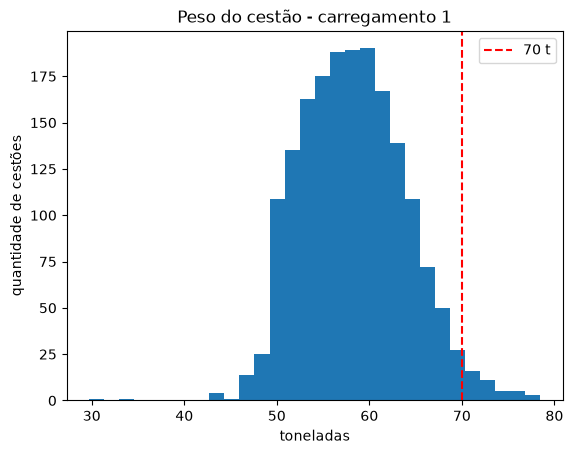

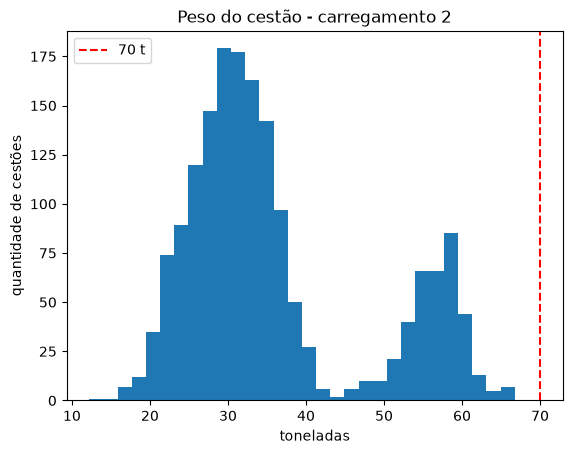

In [17]:
# %% GRÁFICO 1 - Peso dos cestões
for numero in [1, 2]:
    pesos = total[total["nu_carregamento"] == numero]["peso_t"]
    plt.hist(pesos, bins=30)
    plt.axvline(70, color="red", linestyle="--", label="70 t")
    plt.title(f"Peso do cestão - carregamento {numero}")
    plt.xlabel("toneladas")
    plt.ylabel("quantidade de cestões")
    plt.legend()
    plt.show()

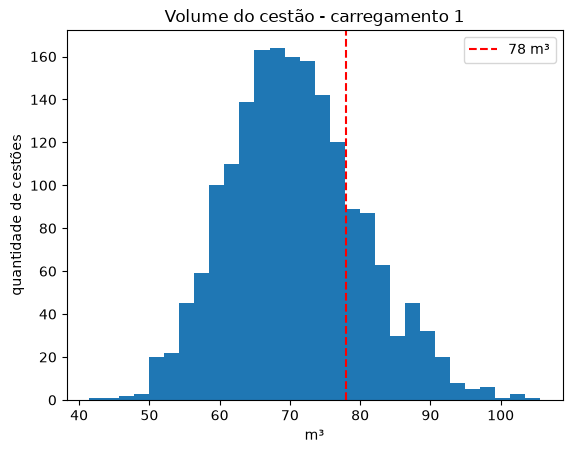

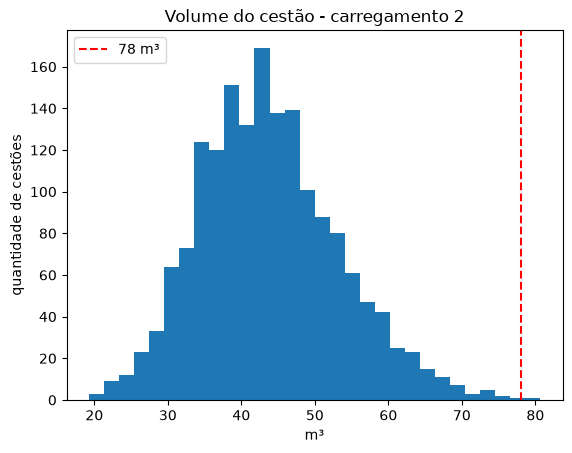

In [18]:
# %% GRÁFICO 2 - Volume dos cestões
for numero in [1, 2]:
    volumes = total[total["nu_carregamento"] == numero]["volume_m3"]
    plt.hist(volumes, bins=30)
    plt.axvline(78, color="red", linestyle="--", label="78 m³")
    plt.title(f"Volume do cestão - carregamento {numero}")
    plt.xlabel("m³")
    plt.ylabel("quantidade de cestões")
    plt.legend()
    plt.show()

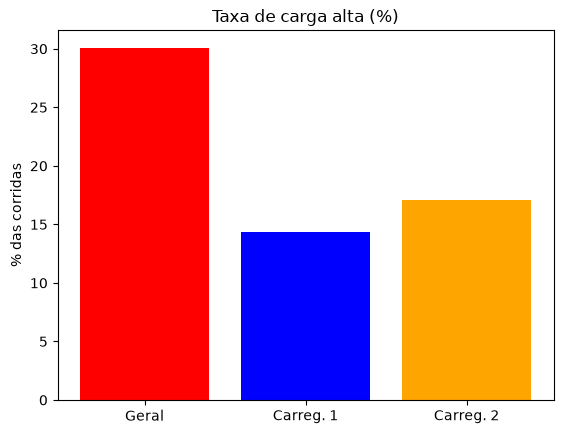

In [19]:
# %% GRÁFICO 3 - Taxa de carga alta
nomes = ["Geral", "Carreg. 1", "Carreg. 2"]
taxas = [geral.mean() * 100, c1.mean() * 100, c2.mean() * 100]
plt.bar(nomes, taxas, color=["red", "blue", "orange"])
plt.title("Taxa de carga alta (%)")
plt.ylabel("% das corridas")
plt.show()

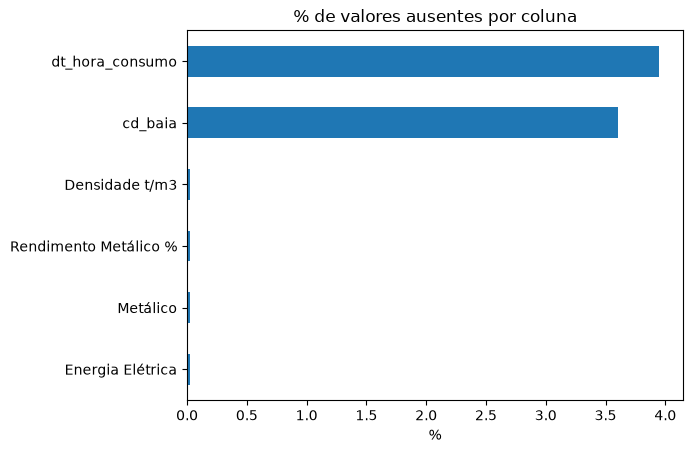

In [20]:
# %% GRÁFICO 4 - Valores ausentes por coluna
nulos = (base.isnull().mean() * 100)
nulos = nulos[nulos > 0].sort_values()
nulos.plot(kind="barh")
plt.title("% de valores ausentes por coluna")
plt.xlabel("%")
plt.show()

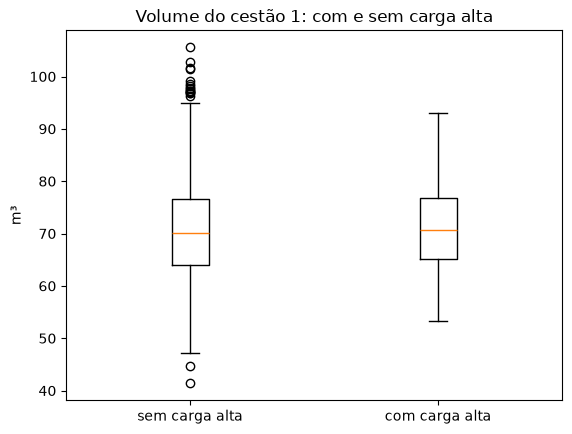

Média sem: 70.7 | média com: 71.3


In [ ]:
# %% GRÁFICO 5 - Volume com e sem carga alta (carregamento 1)
juntos = total.merge(resposta, on="cd_corrida")      # junta as duas tabelas
c1_dados = juntos[juntos["nu_carregamento"] == 1]
sem = c1_dados[c1_dados["is_carga_alta_carregamento_1"] == 0]["volume_m3"]
com = c1_dados[c1_dados["is_carga_alta_carregamento_1"] == 1]["volume_m3"]
plt.boxplot([sem, com], tick_labels=["sem carga alta", "com carga alta"])
plt.title("Volume do cestão 1: com e sem carga alta")
plt.ylabel("m³")
plt.show()
print("Média sem:", round(sem.mean(), 1), "| média com:", round(com.mean(), 1))

# =====================================================================
# GRÁFICOS 8 A 18 - código único
# Coloque base.csv e VariavelResposta.csv na mesma pasta deste arquivo.
# Cada gráfico é salvo na pasta ./graficos/
# =====================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MOSTRAR_NA_TELA = False     # mude para False para só salvar os PNGs, sem abrir janelas

os.makedirs("graficos", exist_ok=True)

# Cores com significado fixo em todos os gráficos
AZUL, VERMELHO, CINZA, LARANJA = "#2b6cb0", "#c0392b", "#7f8c8d", "#dd8a2e"

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})


def mostrar(nome):
    """Ajusta o layout, salva o PNG e (opcionalmente) mostra o gráfico."""
    plt.tight_layout()
    plt.savefig(f"graficos/{nome}.png", dpi=130)
    if MOSTRAR_NA_TELA:
        plt.show()
    else:
        plt.close()


def br(numero):
    """1234 -> '1.234' (milhar com ponto, como no Brasil)."""
    return f"{numero:,}".replace(",", ".")


def pct(valor, casas=1):
    """14.3 -> '14,3%' (vírgula decimal)."""
    return f"{valor:.{casas}f}".replace(".", ",") + "%"


# ---------- PASSO 0b - Ler e preparar os dados
base = pd.read_csv("base.csv")
resposta = pd.read_csv("VariavelResposta.csv")

base["Densidade t/m3"] = base["Densidade t/m3"].str.replace(",", ".").astype(float)
base["dt_hora_consumo"] = pd.to_datetime(base["dt_hora_consumo"], utc=True)
base["peso_t"] = base["qt_peso_carregamento"] / 1000

# Só os cestões (carregamentos 1 e 2) e o volume de cada camada
cestoes = base[base["nu_carregamento"].isin([1, 2])].copy()
cestoes["volume_m3"] = cestoes["peso_t"] / cestoes["Densidade t/m3"]

# Peso e volume de cada cestão (uma linha por corrida + carregamento)
total = cestoes.groupby(["cd_corrida", "nu_carregamento"])[["peso_t", "volume_m3"]].sum()
total = total.reset_index()

# Junta com a resposta e cria a coluna "teve carga alta neste cestão?"
juntos = total.merge(resposta, on="cd_corrida")
juntos["carga_alta"] = np.where(
    juntos["nu_carregamento"] == 1,
    juntos["is_carga_alta_carregamento_1"],
    juntos["is_carga_alta_carregamento_2"],
)

# ---------- GRÁFICO 8 - Corridas por mês (período coberto)
# Horário de Brasília, usando o primeiro carregamento de cada corrida
primeiro = base[base["nu_carregamento"] == 1].groupby("cd_corrida")["dt_hora_consumo"].min().dropna()
primeiro = primeiro.dt.tz_convert("America/Sao_Paulo").dt.tz_localize(None)
por_mes = primeiro.dt.to_period("M").value_counts().sort_index()

nomes_mes = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]
rotulos = [f"{nomes_mes[p.month - 1]}/{str(p.year)[2:]}" for p in por_mes.index]
cores = [CINZA] + [AZUL] * (len(por_mes) - 2) + [CINZA]     # meses das pontas = incompletos

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(rotulos, por_mes.values, color=cores)
ax.bar_label(barras, padding=3)
ax.set_title(
    "Datas das corridas, de ago/2025 a ago/2026 (cinza = mês incompleto)",
    loc="left", fontweight="bold",
)
ax.set_ylabel("corridas")
mostrar("08_corridas_por_mes")

# ---------- GRÁFICO 9 - Carregamentos por tipo
carregamentos = base[["cd_corrida", "nu_carregamento"]].drop_duplicates()
contagem = carregamentos["nu_carregamento"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
nomes = ["Carregamento 1\n(cestão)", "Carregamento 2\n(cestão)", "Carregamento 3\n(gusa líquido)"]
barras = ax.bar(nomes, contagem.values, color=[AZUL, LARANJA, CINZA])
ax.bar_label(barras, labels=[br(v) for v in contagem.values], padding=3)
ax.set_title(
    "Quantidade de carregamentos",
    loc="left", fontweight="bold",
)
ax.set_ylim(0, contagem.max() * 1.12)
ax.set_ylabel("carregamentos")
mostrar("09_carregamentos_por_tipo")

# ---------- GRÁFICO 10 - Cestões que excedem o limite, por motivo
acima_peso = total["peso_t"] > 70
acima_volume = total["volume_m3"] > 78
so_volume = (acima_volume & ~acima_peso).sum()
so_peso = (acima_peso & ~acima_volume).sum()
os_dois = (acima_peso & acima_volume).sum()
excedem = so_volume + so_peso + os_dois

fig, ax = plt.subplots(figsize=(7, 4.5))
nomes = ["Só volume\n(> 78 m³)", "Só peso\n(> 70 t)", "Peso e volume"]
valores = [so_volume, so_peso, os_dois]
barras = ax.bar(nomes, valores, color=VERMELHO)
ax.bar_label(barras, labels=[br(v) for v in valores], padding=3)
ax.set_title(
    "Cestões que excederam o limite",
    loc="left", fontweight="bold", fontsize=11,
)
ax.set_ylim(0, max(valores) * 1.12)
ax.set_ylabel("cestões")
mostrar("10_cestoes_que_excedem")

# ---------- GRÁFICO 11 - Peso contra volume (carregamento 1)
c1 = total[total["nu_carregamento"] == 1]
correlacao = c1["peso_t"].corr(c1["volume_m3"])
passou = (c1["peso_t"] > 70) | (c1["volume_m3"] > 78)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(c1[~passou]["peso_t"], c1[~passou]["volume_m3"], s=10, alpha=0.4, color=AZUL, label="dentro do limite")
ax.scatter(c1[passou]["peso_t"], c1[passou]["volume_m3"], s=10, alpha=0.6, color=VERMELHO, label="excede peso ou volume")
ax.axvline(70, color="black", linestyle="--", linewidth=1)
ax.axhline(78, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("peso do cestão (t)")
ax.set_ylabel("volume estimado (m³)")
ax.set_title(
    f"Peso X Volume (correlação {correlacao:.2f})".replace(".", ","),
    loc="left", fontweight="bold", fontsize=11,
)
ax.legend()
mostrar("11_peso_contra_volume")

# ---------- GRÁFICO 12 - Duração das paradas por carga alta
paradas = resposta[resposta["is_carga_alta"] == 1]["qt_segundos_parada_carga_alta"]
mediana = paradas.median()
media = paradas.mean()
minutos_total = paradas.sum() / 60

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(paradas, bins=40, color=VERMELHO, alpha=0.85)
ax.axvline(mediana, color="black", linestyle="--", label=f"mediana: {mediana:.0f} s")
ax.axvline(media, color=AZUL, linestyle="--", label=f"média: {media:.0f} s")
ax.set_title(
    "Tempo de parada",
    loc="left", fontweight="bold", fontsize=11,
)
ax.set_xlabel("duração da parada (segundos)")
ax.set_ylabel("corridas com carga alta")
ax.legend()
mostrar("12_duracao_das_paradas")

# ---------- GRÁFICO 13 - cd_baia ausente: só no gusa líquido
eh_gusl = base["cd_codigo_material"] == "GUSL"
baia_nula = base["cd_baia"].isnull()
taxa_gusl = baia_nula[eh_gusl].mean() * 100
taxa_outros = baia_nula[~eh_gusl].mean() * 100
# Isso mostra que se, e somente se, o material for GUSL, o cd_baia é nulo.

fig, ax = plt.subplots(figsize=(6.5, 4.5))
nomes = ["GUSL\n(gusa líquido)", "Os outros 22\nmateriais"]
barras = ax.bar(nomes, [taxa_gusl, taxa_outros], color=[VERMELHO, AZUL])
ax.bar_label(barras, labels=[
    f"{pct(taxa_gusl, 0)}\n({br(baia_nula[eh_gusl].sum())} de {br(eh_gusl.sum())})",
    f"{pct(taxa_outros, 0)}\n({br(baia_nula[~eh_gusl].sum())} de {br((~eh_gusl).sum())})",
], padding=3)
ax.set_ylim(0, 125)
ax.set_title(
    "Ausência de cd_baia",
    loc="left", fontweight="bold", fontsize=11,
)
ax.set_ylabel("% de cd_baia ausente")
mostrar("13_cd_baia_ausente")

# ---------- PASSO 14 - Posição relativa de cada camada (usado nos gráficos 14 e 15)
cestoes = cestoes.sort_values(["cd_corrida", "nu_carregamento", "nu_camada"])
ultima_camada = cestoes.groupby(["cd_corrida", "nu_carregamento"])["nu_camada"].transform("max")
cestoes["posicao"] = cestoes["nu_camada"] / ultima_camada
cestoes["faixa"] = pd.cut(cestoes["posicao"], [0, 0.3, 0.7, 1.0], labels=["fundo", "meio", "topo"])

# ---------- GRÁFICO 14 - Onde cada classe de material aparece no cestão
tabela = pd.crosstab(cestoes["tp_material"], cestoes["faixa"], normalize="index") * 100
tabela = tabela.reindex(["Pesado", "Misto", "Leve"])        # Leve fica embaixo no gráfico
leve_meio = tabela.loc["Leve", "meio"]

fig, ax = plt.subplots(figsize=(9, 4.2))
esquerda = np.zeros(len(tabela))
for faixa, cor in [("fundo", AZUL), ("meio", CINZA), ("topo", LARANJA)]:
    ax.barh(tabela.index, tabela[faixa], left=esquerda, color=cor, label=faixa)
    for i, valor in enumerate(tabela[faixa]):
        ax.text(
            esquerda[i] + valor / 2, i, f"{valor:.0f}%".replace(".", ","),
            ha="center", va="center", color="white", fontweight="bold",
        )
    esquerda = esquerda + tabela[faixa].values
ax.set_title(
    "% dos materiais",
    loc="left", fontweight="bold", fontsize=11,
)
ax.set_xlabel("% das linhas de cada classe")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
ax.grid(False)
mostrar("14_onde_cada_classe_aparece")

# ---------- GRÁFICO 15 - Classe da camada de fundo e de topo
classes_cestao = cestoes.groupby(["cd_corrida", "nu_carregamento"])["tp_material"]
fundo = classes_cestao.first().value_counts(normalize=True) * 100
topo = classes_cestao.last().value_counts(normalize=True) * 100
resumo = pd.DataFrame({"Fundo": fundo, "Topo": topo}).fillna(0).T
resumo = resumo.reindex(columns=["Leve", "Misto", "Pesado"]).fillna(0)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
resumo.plot(kind="bar", ax=ax, color=[AZUL, CINZA, VERMELHO], rot=0, width=0.7)
for barra in ax.patches:
    if barra.get_height() > 0:
        ax.text(
            barra.get_x() + barra.get_width() / 2, barra.get_height() + 1.5,
            f"{barra.get_height():.0f}%", ha="center",
        )
ax.set_title(
    "Análise do material leve",
    loc="left", fontweight="bold", fontsize=11,
)
ax.set_ylabel("% dos cestões")
ax.set_ylim(0, 108)
ax.legend(title="Classe da camada", frameon=False)
mostrar("15_fundo_e_topo")

# ---------- GRÁFICO 16 - Resumo dos problemas de qualidade (cada barra tem sua unidade)
colunas_chave = ["cd_corrida", "nu_carregamento", "nu_camada"]
corridas_com_c2 = set(base[base["nu_carregamento"] == 2]["cd_corrida"])
flag_c2_sem_c2 = (
    (resposta["is_carga_alta_carregamento_2"] == 1)
    & (~resposta["cd_corrida"].isin(corridas_com_c2))
).sum()

problemas = {
    "Peso = 0 (linhas)": (base["qt_peso_carregamento"] == 0).sum(),
    "Cestões acima de 70 t ou 78 m³ (cestões)": excedem,
    "Sem horário, fora do GUSL (linhas)": (base["dt_hora_consumo"].isnull() & ~eh_gusl).sum(),
    "Carreg. 3 com sucata, não GUSL (linhas)": ((base["nu_carregamento"] == 3) & ~eh_gusl).sum(),
    "Chave de camada repetida (linhas)": base.duplicated(colunas_chave).sum(),
    "Sem densidade: RECG e RECC (linhas)": base["Densidade t/m3"].isnull().sum(),
    "Carga alta no carreg. 2 sem ele na base (corridas)": flag_c2_sem_c2,
    "Linhas 100% duplicadas (linhas)": base.duplicated().sum(),
}
problemas = pd.Series(problemas).sort_values()

fig, ax = plt.subplots(figsize=(10, 4.8))
barras = ax.barh(problemas.index, problemas.values, color=VERMELHO, alpha=0.85)
ax.bar_label(barras, labels=[br(int(v)) for v in problemas.values], padding=3)
ax.set_xlim(0, problemas.max() * 1.12)
fig.suptitle(
    '"Problemas"',
    x=0.01, ha="left", fontweight="bold", fontsize=11,
)
ax.set_xlabel("ocorrências (a unidade está no nome de cada barra)")
mostrar("16_resumo_de_problemas")

# ---------- GRÁFICO 17 - Volume do cestão 2: com e sem carga alta
c2 = juntos[juntos["nu_carregamento"] == 2]
sem = c2[c2["carga_alta"] == 0]["volume_m3"]
com = c2[c2["carga_alta"] == 1]["volume_m3"]

fig, ax = plt.subplots(figsize=(6.5, 4.8))
caixas = ax.boxplot(
    [sem, com], tick_labels=["sem carga alta", "com carga alta"],
    patch_artist=True, showfliers=False,
)
for caixa, cor in zip(caixas["boxes"], [AZUL, VERMELHO]):
    caixa.set_facecolor(cor)
    caixa.set_alpha(0.6)
ax.axhline(78, color="black", linestyle="--", linewidth=1)
ax.text(1.5, 78.8, "78 m³", ha="center")
ax.set_title(
    "Cestão 2: volume médio",
    loc="left", fontweight="bold", fontsize=11,
)
ax.set_ylabel("volume estimado (m³)")
mostrar("17_volume_cestao2_com_e_sem_carga_alta")

# ---------- GRÁFICO 18 - Carga alta por faixa de peso (carregamento 1) - PRÉVIA
c1j = juntos[juntos["nu_carregamento"] == 1].copy()
c1j["faixa_peso"] = pd.cut(
    c1j["peso_t"], [0, 50, 55, 60, 65, 70, 100],
    labels=["até 50 t", "50 a 55 t", "55 a 60 t", "60 a 65 t", "65 a 70 t", "acima de 70 t"],
)
por_faixa = c1j.groupby("faixa_peso", observed=True)["carga_alta"].agg(["size", "mean"])
media_geral = c1j["carga_alta"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4.8))
barras = ax.bar(por_faixa.index.astype(str), por_faixa["mean"] * 100, color=VERMELHO, alpha=0.85)
rotulos = []
for n, m in zip(por_faixa["size"], por_faixa["mean"]):
    aviso = "\npoucos casos" if n < 100 else ""
    rotulos.append(f"{pct(m * 100)}\n(n={br(n)}){aviso}")
ax.bar_label(barras, labels=rotulos, padding=3, fontsize=9)
ax.axhline(media_geral, color="black", linestyle="--", linewidth=1)
ax.text(len(por_faixa) - 0.5, media_geral + 1, f"média: {pct(media_geral)}", ha="right")
ax.set_ylim(0, por_faixa["mean"].max() * 100 * 1.25)
ax.set_title(
    "Carregamento 1: % de carga alta pelo peso do cestão",
    loc="left", fontweight="bold", fontsize=11,
)
ax.set_xlabel("peso do cestão")
ax.set_ylabel("% com carga alta")
mostrar("18_carga_alta_por_faixa_de_peso")

In [26]:
#==========================================
# PARTE 3: LIMPANDO OS DADOS
#==========================================

# Verifica se existe algum valor com parte decimal diferente de zero
carregamento_tem_decimal = (base["nu_carregamento"] % 1 != 0).any()
camada_tem_decimal = (base["nu_camada"] % 1 != 0).any()

print("nu_carregamento tem valor não-inteiro?", carregamento_tem_decimal)
print("nu_camada tem valor não-inteiro?", camada_tem_decimal)

# Se quiser ver quais linhas são as "culpadas" (caso dê True em algum dos dois)
print(base[base["nu_carregamento"] % 1 != 0])
print(base[base["nu_camada"] % 1 != 0])

if (carregamento_tem_decimal == False and camada_tem_decimal == False):
    base["nu_carregamento"] = base["nu_carregamento"].astype(int)
    base["nu_camada"] = base["nu_camada"].astype(int)
    base.to_csv("base_limpo.csv", index=False)

nu_carregamento tem valor não-inteiro? False
nu_camada tem valor não-inteiro? False
Empty DataFrame
Columns: [pk_aci_corrida, cd_corrida, nu_carregamento, nu_camada, cd_codigo_material, qt_peso_carregamento, ds_descricao_material_x, cd_baia, dt_hora_consumo, ds_descricao_material_y, tp_material, Metálico, Energia Elétrica, Densidade t/m3, Rendimento Metálico %, peso_t]
Index: []
Empty DataFrame
Columns: [pk_aci_corrida, cd_corrida, nu_carregamento, nu_camada, cd_codigo_material, qt_peso_carregamento, ds_descricao_material_x, cd_baia, dt_hora_consumo, ds_descricao_material_y, tp_material, Metálico, Energia Elétrica, Densidade t/m3, Rendimento Metálico %, peso_t]
Index: []


In [ ]:
base["dt_hora_consumo"] = base["dt_hora_consumo"].dt.tz_convert("America/Sao_Paulo")
print(base["dt_hora_consumo"].dtype)
base.to_csv("base_limpo.csv", index=False)

base["dt_hora_consumo_br"] = 0;

datetime64[us, America/Sao_Paulo]
